# Figure 5 -- Mechanism (LPS, DNA, safety)

In [1]:
import matplotlib as mpl, matplotlib.pyplot as plt
import pandas as pd,numpy as np,matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap,TwoSlopeNorm
from scipy.stats import kruskal
import pingouin as pg
import seaborn as sns,warnings
warnings.filterwarnings('ignore')

mpl.font_manager._load_fontmanager(try_read_cache=False)
plt.style.use('seaborn-v0_8-paper')
plt.rcParams.update({
    'font.size':7,'axes.titlesize':7,'axes.labelsize':6.5,
    'xtick.labelsize':6,'ytick.labelsize':6,'legend.fontsize':6,
    'axes.linewidth':0.5,'axes.edgecolor':'#888888',
    'xtick.color':'#555555','ytick.color':'#555555',
    'axes.labelcolor':'#333333','font.family':'sans-serif',
    'font.sans-serif':['Arial','Liberation Sans','DejaVu Sans'],
    'figure.dpi':300,'savefig.dpi':600,
    'xtick.major.width':0.5,'ytick.major.width':0.5,
    'xtick.major.size':2.5,'ytick.major.size':2.5,
    'xtick.major.pad':2,'ytick.major.pad':2,
    'axes.spines.top':False,'axes.spines.right':False,
})
DATA='/home/pszymczak/code/omegamp-dashboard/data/'
ref=pd.read_csv(DATA+'omegamp_reference_table.csv')
mic=pd.read_csv(DATA+'mic.csv'); hc50=pd.read_csv(DATA+'hc50.csv'); cc50=pd.read_csv(DATA+'cc50.csv')
_dc = lambda v: float(str(v).lstrip('>')) if pd.notna(v) else float('nan')
for _c in mic.columns[1:]:
    mic[_c] = mic[_c].apply(_dc)
hc50['HC50'] = hc50['HC50'].apply(_dc)
cc50['CC50'] = cc50['CC50'].apply(_dc)

npn=pd.read_csv(DATA+'npn.csv'); disc=pd.read_csv(DATA+'disc.csv')
npn_fc=pd.read_csv(DATA+'npn_fc.csv'); disc_fc=pd.read_csv(DATA+'disc_fc.csv')
lps_raw=pd.read_csv(DATA+'lps_binding.csv'); dna=pd.read_csv(DATA+'dna_binding.csv')

df=ref.merge(hc50,on='short_name',how='left').merge(cc50,on='short_name',how='left')
df=df.merge(npn.rename(columns={'MaxRel':'NPN','AUC':'NPN_AUC'}),on='short_name',how='left')
df=df.merge(disc.rename(columns={'MaxRel':'DiSC','AUC':'DiSC_AUC'}),on='short_name',how='left')
df=df.merge(npn_fc[['short_name','MaxRel']].rename(columns={'MaxRel':'NPN_fc'}),on='short_name',how='left')
df=df.merge(disc_fc[['short_name','MaxRel']].rename(columns={'MaxRel':'DiSC_fc'}),on='short_name',how='left')
df=df.merge(npn_fc[['short_name','concentration_uM']].rename(columns={'concentration_uM':'fc_conc'}),on='short_name',how='left')
ms=mic.columns[1:]; mv=mic[ms].astype(float)
mic['mic50']=mv.fillna(128).clip(upper=128).median(axis=1)
mic['nle2']=(mv<=2).sum(axis=1); mic['nle4']=(mv<=4).sum(axis=1)
df=df.merge(mic[['short_name','mic50','nle2','nle4']],on='short_name',how='left')
df['HC50']=df['HC50'].clip(0.1,128); df['CC50']=df['CC50'].clip(0.1,128)

pm={'DBAASPS_20015':'As-CATH4-6L','DBAASPS_20955':'OP-145-TII4'}
def gf(r):
    if r['category']=='prototype':
        for f in ['BoCo1','GQ20','Mammutin-1','DeNo1047','cecropin','LG21','pa4','sarcotoxin','bZIP']:
            if f.lower() in r['short_name'].lower() or f==r['short_name']: return f
        if 'OP-145' in r['short_name']: return 'OP-145-TII4'
        if 'As-CATH' in r['short_name']: return 'As-CATH4-6L'
        return r['short_name']
    p=str(r.get('prototype','')); return pm.get(p,p) if p!='nan' else ''
df['family']=df.apply(gf,axis=1)
CL='#0072B2'; CD='#D55E00'
def oc(f): return CD if f=='bZIP' else CL
MO=['cecropin','LG21','pa4','sarcotoxin','bZIP']
LF=['cecropin','LG21','pa4','sarcotoxin']

LEADS_SHORT={
    'Ω-AMT-cecropin-1':'Ω-C-1','Ω-AMT-cecropin-4':'Ω-C-4',
    'Ω-AMT-pa4-1':'Ω-P-1','Ω-AMT-sarcotoxin-4':'Ω-S-4',
    'Ω-MT-bZIP-8':'Ω-Z-8',
}
LEADS_FULL={
    'Ω-AMT-cecropin-1':'Ω-cecropin-1','Ω-AMT-cecropin-4':'Ω-cecropin-4',
    'Ω-AMT-pa4-1':'Ω-pa4-1','Ω-AMT-sarcotoxin-4':'Ω-sarcotoxin-4',
    'Ω-MT-bZIP-8':'Ω-bZIP-8',
}
LS=set(LEADS_SHORT.keys())

LEAD_OFFSETS_D={
    'Ω-AMT-cecropin-1':(8,10),'Ω-AMT-cecropin-4':(8,16),
    'Ω-AMT-pa4-1':(8,12),'Ω-AMT-sarcotoxin-4':(8,-12),
    'Ω-MT-bZIP-8':(8,-12),
}
LEAD_OFFSETS_E={
    'Ω-AMT-cecropin-1':(8,12),'Ω-AMT-cecropin-4':(8,10),
    'Ω-AMT-pa4-1':(8,14),'Ω-AMT-sarcotoxin-4':(8,-14),
    'Ω-MT-bZIP-8':(8,12),
}

def annotate_lead(ax,x,y,label,offset=(10,8)):
    ax.annotate(label,(x,y),fontsize=6,ha='left',va='center',color='black',
                xytext=offset,textcoords='offset points',
                arrowprops=dict(arrowstyle='-',color='#555',lw=0.4),zorder=10,
                annotation_clip=True)

QC={'NPN dom.':'#009E73','Both strong':'#117733','DiSC dom.':'#AA3377','Both weak':'#BBBBBB'}
QO=['NPN dom.','Both strong','DiSC dom.','Both weak']
me=df.dropna(subset=['NPN','DiSC']).copy()
nm=me['NPN'].median(); dm=me['DiSC'].median()
def aq(r):
    n,d=r['NPN']>=nm,r['DiSC']>=dm
    if n and not d: return 'NPN dom.'
    if not n and d: return 'DiSC dom.'
    if n and d: return 'Both strong'
    return 'Both weak'
me['quad']=me.apply(aq,axis=1)

SF={s:v for s,v in {
    'A. baumannii ATCC 19606 (-)':('Ab. 19606',False,'-'),
    'A. baumannii ATCC BAA-1605 (-) - CGTPACCIMRA':('Ab. BAA-1605',True,'-'),
    'E. cloacae ATCC 13047 (-)':('Ecl. 13047',False,'-'),
    'E. coli ATCC 11775 (-)':('Ec. 11775',False,'-'),
    'E. coli AIC221 (-)':('Ec. AIC221',False,'-'),
    'E. coli AIC222 - CRE (-)':('Ec. AIC222',True,'-'),
    'E. coli ATCC BAA-3170 (-) - CRE':('Ec. BAA-3170',True,'-'),
    'K. pneumoniae ATCC 13883 (-)':('Kp. 13883',False,'-'),
    'K. pneumoniae ATCC BAA-2342 (-) - EIRK':('Kp. BAA-2342',True,'-'),
    'P. aeruginosa PAO1 (-)':('Pa. PAO1',False,'-'),
    'P. aeruginosa PA14 (-)':('Pa. PA14',False,'-'),
    'P. aeruginosa ATCC BAA-3197 (-) - FBCRP':('Pa. BAA-3197',True,'-'),
    'S. enterica ATCC 9150 (-)':('Se. 9150',False,'-'),
    'S. enterica Typhimurtium ATCC 700720':('Se. Typhimurium',False,'-'),
    'B. subtilis ATCC 23857 (+)':('Bs. 23857',False,'+'),
    'S. aureus ATCC 12600 (+)':('Sa. 12600',False,'+'),
    'S. aureus ATCC BAA-1556 - MRSA (+)':('Sa. BAA-1556',True,'+'),
    'E. faecalis ATCC 700802 - VRE (+)':('Ef. 700802',True,'+'),
    'E. faecium ATCC 700221 - VRE (+)':('Efm. 700221',True,'+'),
    'E. coli K-12 BW25113 (-)':('Ec. K-12',False,'-'),
}.items()}

# $\it{species}$ renders species italic via mathtext; identifier stays upright as plain text.
# MDR bold is applied via set_fontweight('bold') in _jbar (affects plain text identifier).
STRAIN_LABELS={
    'A. baumannii ATCC 19606 (-)':               '$\\it{A. baumannii}$ ATCC 19606',
    'A. baumannii ATCC BAA-1605 (-) - CGTPACCIMRA':'$\\it{A. baumannii}$ ATCC BAA-1605',
    'E. cloacae ATCC 13047 (-)':                 '$\\it{E. cloacae}$ ATCC 13047',
    'E. coli ATCC 11775 (-)':                    '$\\it{E. coli}$ ATCC 11775',
    'E. coli AIC221 (-)':                        '$\\it{E. coli}$ AIC221',
    'E. coli AIC222 - CRE (-)':                  '$\\it{E. coli}$ AIC222',
    'E. coli ATCC BAA-3170 (-) - CRE':           '$\\it{E. coli}$ ATCC BAA-3170',
    'K. pneumoniae ATCC 13883 (-)':              '$\\it{K. pneumoniae}$ ATCC 13883',
    'K. pneumoniae ATCC BAA-2342 (-) - EIRK':    '$\\it{K. pneumoniae}$ ATCC BAA-2342',
    'P. aeruginosa PAO1 (-)':                    '$\\it{P. aeruginosa}$ PAO1',
    'P. aeruginosa PA14 (-)':                    '$\\it{P. aeruginosa}$ PA14',
    'P. aeruginosa ATCC BAA-3197 (-) - FBCRP':   '$\\it{P. aeruginosa}$ ATCC BAA-3197',
    'S. enterica ATCC 9150 (-)':                 '$\\it{S. enterica}$ ATCC 9150',
    'S. enterica Typhimurtium ATCC 700720':       '$\\it{S. enterica}$ Typhimurium',
    'B. subtilis ATCC 23857 (+)':                '$\\it{B. subtilis}$ ATCC 23857',
    'S. aureus ATCC 12600 (+)':                  '$\\it{S. aureus}$ ATCC 12600',
    'S. aureus ATCC BAA-1556 - MRSA (+)':        '$\\it{S. aureus}$ ATCC BAA-1556',
    'E. faecalis ATCC 700802 - VRE (+)':         '$\\it{E. faecalis}$ ATCC 700802',
    'E. faecium ATCC 700221 - VRE (+)':          '$\\it{E. faecium}$ ATCC 700221',
    'E. coli K-12 BW25113 (-)':                  '$\\it{E. coli}$ K-12 BW25113',
}

mic_cmap=LinearSegmentedColormap.from_list('mic_rb',[(0.0,'#b2182b'),(0.25,'#ef8a62'),(0.5,'#f7f7f7'),(0.75,'#67a9cf'),(1.0,'#2166ac')])
mic_norm=TwoSlopeNorm(vmin=0,vcenter=32,vmax=64)
PL=dict(fontsize=9,fontweight='bold',va='top',ha='left')
print(f'Ready: {len(me)}')

Ready: 195


  export box: 6.43 x 7.89 in (x +0.04..6.47, y +0.07..7.96; Cell max 6.5 x 8)


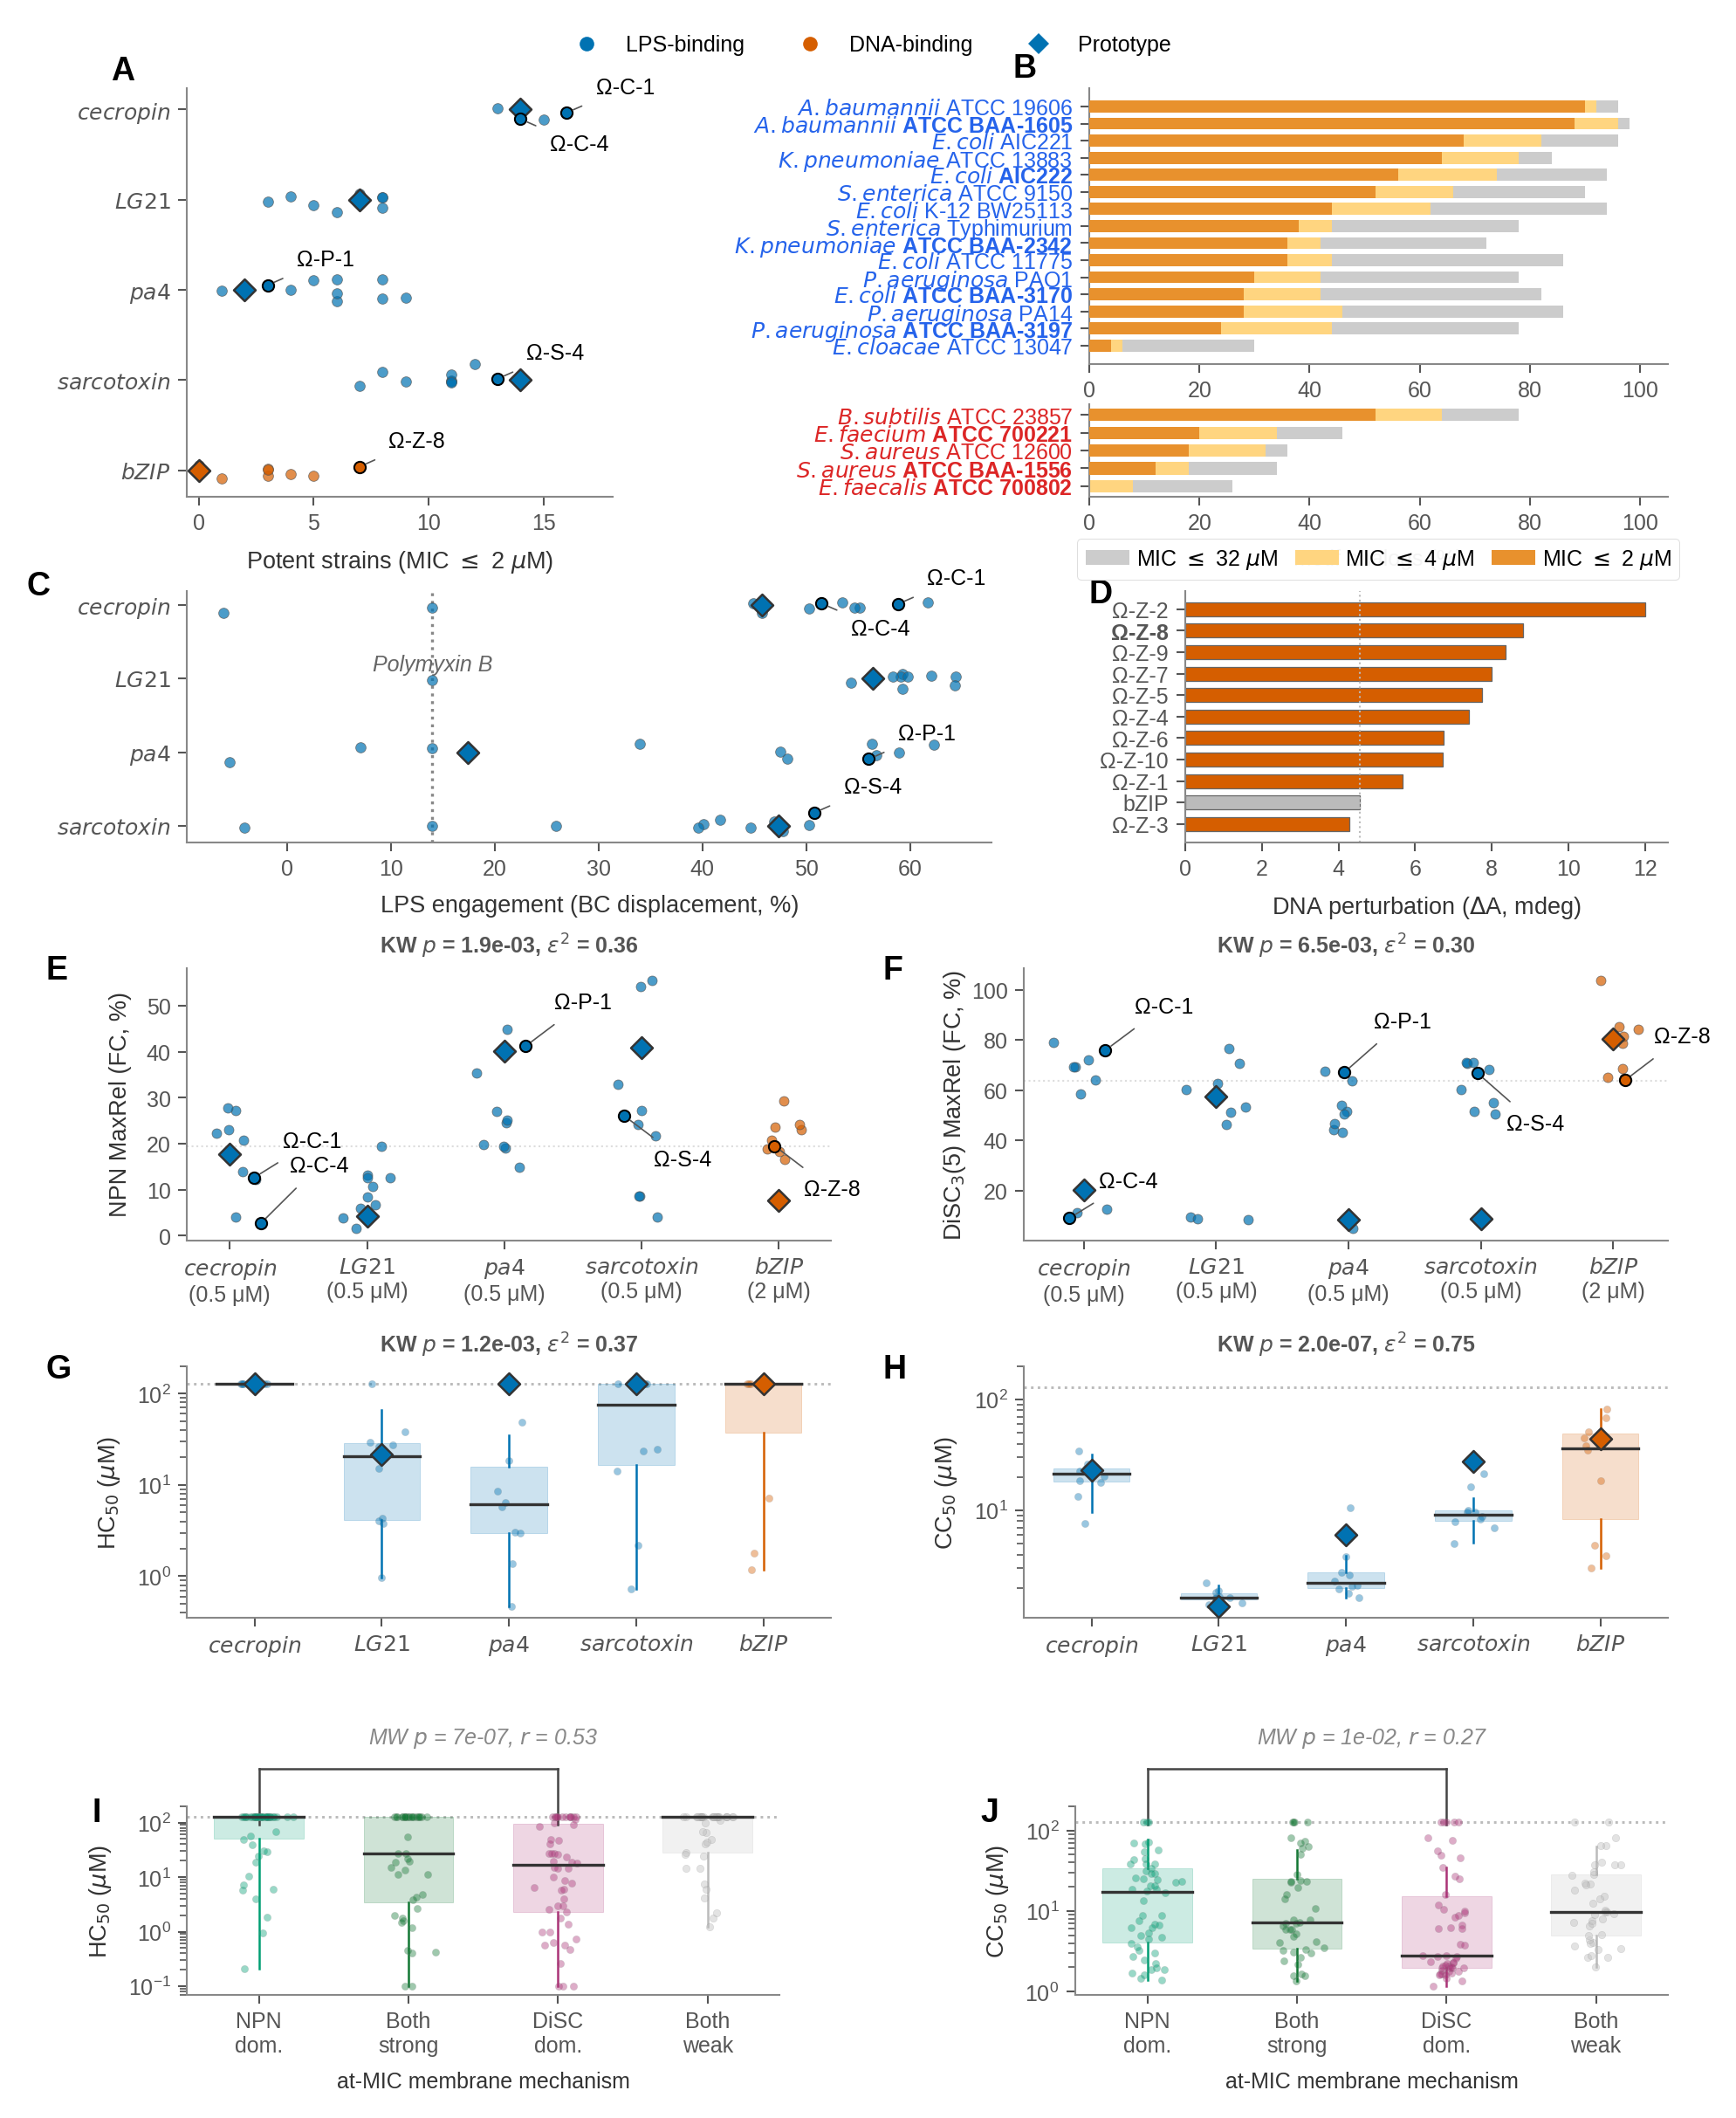

Saved figure5_mechanism


In [2]:
fig=plt.figure(figsize=(6.5,8.0),dpi=300)

# Row 1: A (left) | B — coverage bar plot (right, wider gap, B narrower)
gs_a  = gridspec.GridSpec(1,1,figure=fig,left=0.10,right=0.35,top=0.965,bottom=0.770)
gs_b  = gridspec.GridSpec(1,1,figure=fig,left=0.63,right=0.97,top=0.965,bottom=0.770)
# Row 2: C (LPS) | D (DNA)
gs_cd = gridspec.GridSpec(1,2,figure=fig,left=0.10,right=0.97,top=0.725,bottom=0.605,wspace=0.30,width_ratios=[2,1.2])
# Row 3: E (NPN FC) | F (DiSC FC)
gs_gh = gridspec.GridSpec(1,2,figure=fig,left=0.10,right=0.97,top=0.545,bottom=0.415,wspace=0.30)
# Row 4: G (HC50) | H (CC50)
gs_ef = gridspec.GridSpec(1,2,figure=fig,left=0.10,right=0.97,top=0.355,bottom=0.235,wspace=0.30)
# Row 5: I (HC50 at-MIC) | J (CC50 at-MIC)
gs_ij = gridspec.GridSpec(1,2,figure=fig,left=0.10,right=0.97,top=0.145,bottom=0.055,wspace=0.50)

la=lps_raw.groupby(['short_name','family','concentration','calcium'])['BC_displacement'].mean().reset_index()
la=la.merge(ref[['short_name','category']],on='short_name',how='left')
ma=df[(df['family'].isin(MO))&(df['category']=='analog')].copy()
mfc=df[df['family'].isin(MO)].copy()

# A — MIC potency by conditioning family
ax=fig.add_subplot(gs_a[0]); ax.text(-0.18,1.08,'A',transform=ax.transAxes,**PL)
for i,f in enumerate(MO):
    c=oc(f); fd=df[df['family']==f]; pr=fd[fd['category']=='prototype']; an=fd[fd['category']=='analog']
    if len(pr)>0: ax.scatter(pr['nle2'],i,marker='D',c=c,edgecolors='#333',lw=0.6,s=18,zorder=5)
    if len(an)>0:
        j=np.random.RandomState(42+i).normal(0,0.07,len(an))
        lead_k=0
        for k,(_,r) in enumerate(an.iterrows()):
            if r['short_name'] in LS:
                ax.scatter(r['nle2'],i+j[k],c=c,s=10,edgecolors='black',linewidth=0.5,zorder=5)
                dy=7 if lead_k%2==0 else -7
                annotate_lead(ax,r['nle2'],i+j[k],LEADS_SHORT[r['short_name']],(8,dy))
                lead_k+=1
            else:
                ax.scatter(r['nle2'],i+j[k],c=c,s=8,alpha=0.7,edgecolors='#555',lw=0.2,zorder=4)
ax.set_yticks(range(5)); ax.set_yticklabels([f'$\\it{{{f}}}$' for f in MO],fontsize=6)
ax.invert_yaxis(); ax.set_xlabel('Potent strains (MIC $\\leq$ 2 $\\mu$M)'); ax.set_xlim(-0.5,18)

# C — LPS binding with Polymyxin B reference line
ax=fig.add_subplot(gs_cd[0]); ax.text(-0.20,1.08,'C',transform=ax.transAxes,**PL)
for i,f in enumerate(LF):
    fd=la[(la['family']==f)&(la['concentration']==2)&la['calcium'].str.contains('no',case=False,na=False)]
    pr=fd[fd['category']=='prototype']; an=fd[fd['category']!='prototype']
    if len(pr)>0: ax.scatter(pr['BC_displacement'],i,marker='D',c=CL,edgecolors='#333',lw=0.6,s=18,zorder=5)
    if len(an)>0:
        j=np.random.RandomState(42+i).normal(0,0.07,len(an))
        lead_k=0
        for k,(_,r) in enumerate(an.iterrows()):
            if r['short_name'] in LS:
                ax.scatter(r['BC_displacement'],i+j[k],c=CL,s=10,edgecolors='black',linewidth=0.5,zorder=5)
                dy=7 if lead_k%2==0 else -7
                annotate_lead(ax,r['BC_displacement'],i+j[k],LEADS_SHORT[r['short_name']],(8,dy))
                lead_k+=1
            else:
                ax.scatter(r['BC_displacement'],i+j[k],c=CL,s=8,alpha=0.7,edgecolors='#555',lw=0.2,zorder=4)
pmb_disp=la[(la['short_name']=='Polymyxin B')&(la['concentration']==2)&
             la['calcium'].str.contains('no',case=False,na=False)]['BC_displacement'].mean()
ax.axvline(pmb_disp,color='#888',ls=':',lw=0.8,zorder=1)
ax.text(pmb_disp,0.75,'Polymyxin B',fontsize=6,color='#666',ha='center',va='top',
        transform=ax.get_xaxis_transform(),style='italic')
ax.set_yticks(range(4)); ax.set_yticklabels([f'$\\it{{{f}}}$' for f in LF],fontsize=6)
ax.invert_yaxis(); ax.set_xlabel('LPS engagement (BC displacement, %)')

# D — DNA binding
ax=fig.add_subplot(gs_cd[1]); ax.text(-0.20,1.05,'D',transform=ax.transAxes,**PL)
d12=dna[(dna['metric']=='deltaA')&(dna['concentration']==12.5)].copy()
d12=d12.merge(ref[['short_name','category']],on='short_name',how='left')
d12=d12.sort_values('value',ascending=True).reset_index(drop=True)
y=np.arange(len(d12))
cb_colors=['#bbb' if c=='prototype' else CD for c in d12['category']]
ax.barh(y,d12['value'],color=cb_colors,edgecolor='#666',lw=0.3,height=0.65)
bv=d12[d12['category']=='prototype']['value']
if len(bv)>0: ax.axvline(bv.values[0],color='#bbb',ls=':',lw=0.5)
lb=['bZIP' if c=='prototype' else f"Ω-Z-{n.split('-')[-1]}" for c,n in zip(d12['category'],d12['short_name'])]
ax.set_yticks(y); ax.set_yticklabels(lb,fontsize=6)
for i,(_,r) in enumerate(d12.iterrows()):
    if r['short_name'] in LS: ax.get_yticklabels()[i].set_fontweight('bold')
ax.set_xlabel('DNA perturbation ($\\Delta$A, mdeg)')

fig.legend([Line2D([],[],marker='o',color=CL,lw=0,ms=4,markeredgecolor='#555'),
            Line2D([],[],marker='o',color=CD,lw=0,ms=4,markeredgecolor='#555'),
            Line2D([],[],marker='D',color=CL,markeredgecolor='#333',lw=0,ms=4)],
           ['LPS-binding','DNA-binding','Prototype'],
           loc='upper center',bbox_to_anchor=(0.50,1.00),ncol=3,fontsize=6,frameon=False)

def boxstrip(ax,dd,order,colors):
    for i,k in enumerate(order):
        v=dd.get(k,np.array([]))
        if len(v)==0: continue
        c=colors[k] if isinstance(colors,dict) else colors(k)
        q1,md,q3=np.percentile(v,[25,50,75]); iq=q3-q1
        lo=max(v.min(),q1-1.5*iq); hi=min(v.max(),q3+1.5*iq)
        ax.fill_between([i-0.3,i+0.3],q1,q3,color=c,alpha=0.2,zorder=2)
        ax.plot([i-0.3,i+0.3],[md,md],color='#333',lw=0.8,zorder=4)
        ax.plot([i,i],[lo,q1],color=c,lw=0.6,zorder=2); ax.plot([i,i],[q3,hi],color=c,lw=0.6,zorder=2)
        jt=np.random.RandomState(i+50).normal(0,0.07,len(v))
        ax.scatter(np.full(len(v),i)+jt,v,c=c,s=4,alpha=0.4,edgecolors='#888',lw=0.1,zorder=3)
    ax.set_yscale('log')

def bracket(ax, x1, x2, txt):
    trans=ax.get_xaxis_transform()
    bar_y=1.20; tick_y=0.90
    ax.plot([x1,x1],[tick_y,bar_y],transform=trans,color='#444',lw=0.6,clip_on=False)
    ax.plot([x2,x2],[tick_y,bar_y],transform=trans,color='#444',lw=0.6,clip_on=False)
    ax.plot([x1,x2],[bar_y,bar_y],transform=trans,color='#444',lw=0.6,clip_on=False)
    ax.text(0.5,1.30,txt,transform=ax.transAxes,ha='center',va='bottom',fontsize=6,color='#888',style='italic')

def kw_eta2(groups):
    H,p=kruskal(*groups); n=sum(len(g) for g in groups)
    return p, H/(n-1)

def kw_label(ax,groups):
    p,e2=kw_eta2(groups)
    ax.text(0.5,1.03,f'KW $p$ = {p:.1e}, $\\varepsilon^2$ = {e2:.2f}',
            transform=ax.transAxes,fontsize=6,ha='center',va='bottom',color='#555',fontweight='bold')

CAP=128; CAP_TOP=200  # ylim top for HC50/CC50 panels so cap markers are fully visible

# E — NPN at fixed concentration by conditioning family
# Fixed per-family assay concentration, read from npn_fc.csv so the E/F
# axis labels can never drift from the data.
FAM_CONC_COND={}
for _f in MO:
    _v=df.loc[df['family']==_f,'fc_conc'].dropna().unique()
    FAM_CONC_COND[_f]=_v[0] if len(_v) else np.nan
ax=fig.add_subplot(gs_gh[0]); ax.text(-0.22,1.05,'E',transform=ax.transAxes,**PL)
nm_fc=mfc[mfc['category']=='analog']['NPN_fc'].dropna().median()
for j_idx,f in enumerate(MO):
    c=oc(f)
    an=mfc[(mfc['family']==f)&(mfc['category']=='analog')]
    pr=mfc[(mfc['family']==f)&(mfc['category']=='prototype')]
    jt=np.random.RandomState(j_idx*7).normal(0,0.1,len(an)) if len(an)>0 else []
    for k,(_,r) in enumerate(an.iterrows()):
        if pd.isna(r['NPN_fc']): continue
        if r['short_name'] in LS:
            ax.scatter(j_idx+jt[k],r['NPN_fc'],c=c,s=10,edgecolors='black',linewidth=0.5,zorder=5)
            off=LEAD_OFFSETS_D.get(r['short_name'],(6,8))
            annotate_lead(ax,j_idx+jt[k],r['NPN_fc'],LEADS_SHORT[r['short_name']],off)
        else:
            ax.scatter(j_idx+jt[k],r['NPN_fc'],c=c,s=7,alpha=0.7,edgecolors='#555',lw=0.2,zorder=3)
    if len(pr)>0:
        pv=pr['NPN_fc'].dropna().values
        if len(pv)>0: ax.scatter([j_idx],pv,marker='D',c=c,edgecolors='#333',lw=0.6,s=18,zorder=5)
ax.axhline(nm_fc,color='#ddd',ls=':',lw=0.5,zorder=1)
ax.set_xticks(range(5))
ax.set_xticklabels([f'$\\it{{{f}}}$\n({FAM_CONC_COND[f]:g} μM)' for f in MO],fontsize=6)
ax.set_ylabel('NPN MaxRel (FC, %)')
gs_npn_fc=[mfc[(mfc['family']==f)&(mfc['category']=='analog')]['NPN_fc'].dropna().values for f in MO]
gs_npn_fc=[g for g in gs_npn_fc if len(g)>0]
if len(gs_npn_fc)>=2: kw_label(ax,gs_npn_fc)

# F — DiSC at fixed concentration by conditioning family
ax=fig.add_subplot(gs_gh[1]); ax.text(-0.22,1.05,'F',transform=ax.transAxes,**PL)
dm_fc=mfc[mfc['category']=='analog']['DiSC_fc'].dropna().median()
for j_idx,f in enumerate(MO):
    c=oc(f)
    an=mfc[(mfc['family']==f)&(mfc['category']=='analog')]
    pr=mfc[(mfc['family']==f)&(mfc['category']=='prototype')]
    jt=np.random.RandomState(j_idx*7+1).normal(0,0.1,len(an)) if len(an)>0 else []
    for k,(_,r) in enumerate(an.iterrows()):
        if pd.isna(r['DiSC_fc']): continue
        if r['short_name'] in LS:
            ax.scatter(j_idx+jt[k],r['DiSC_fc'],c=c,s=10,edgecolors='black',linewidth=0.5,zorder=5)
            off=LEAD_OFFSETS_E.get(r['short_name'],(6,8))
            annotate_lead(ax,j_idx+jt[k],r['DiSC_fc'],LEADS_SHORT[r['short_name']],off)
        else:
            ax.scatter(j_idx+jt[k],r['DiSC_fc'],c=c,s=7,alpha=0.7,edgecolors='#555',lw=0.2,zorder=3)
    if len(pr)>0:
        pv=pr['DiSC_fc'].dropna().values
        if len(pv)>0: ax.scatter([j_idx],pv,marker='D',c=c,edgecolors='#333',lw=0.6,s=18,zorder=5)
ax.axhline(dm_fc,color='#ddd',ls=':',lw=0.5,zorder=1)
ax.set_xticks(range(5))
ax.set_xticklabels([f'$\\it{{{f}}}$\n({FAM_CONC_COND[f]:g} μM)' for f in MO],fontsize=6)
ax.set_ylabel('DiSC$_3$(5) MaxRel (FC, %)',labelpad=1)
gs_disc_fc=[mfc[(mfc['family']==f)&(mfc['category']=='analog')]['DiSC_fc'].dropna().values for f in MO]
gs_disc_fc=[g for g in gs_disc_fc if len(g)>0]
if len(gs_disc_fc)>=2: kw_label(ax,gs_disc_fc)

# G — HC50 by conditioning family
ax=fig.add_subplot(gs_ef[0]); ax.text(-0.22,1.05,'G',transform=ax.transAxes,**PL)
hcd={f:ma[ma['family']==f]['HC50'].dropna().values for f in MO}
boxstrip(ax,hcd,MO,{f:oc(f) for f in MO})
for i,f in enumerate(MO):
    pr=df[(df['family']==f)&(df['category']=='prototype')]
    if len(pr)>0 and pd.notna(pr['HC50'].values[0]): ax.scatter([i],pr['HC50'].values[0],marker='D',c=oc(f),edgecolors='#333',lw=0.6,s=18,zorder=5)
ax.set_xticks(range(5)); ax.set_xticklabels([f'$\\it{{{f}}}$' for f in MO],fontsize=6)
ax.set_ylabel('HC$_{50}$ ($\\mu$M)')
ax.axhline(CAP,color='#bbb',ls=':',lw=0.7,zorder=1); ax.set_ylim(top=CAP_TOP)
gs_hcd=[v for v in hcd.values() if len(v)>0]
if len(gs_hcd)>=2: kw_label(ax,gs_hcd)

# H — CC50 by conditioning family
ax=fig.add_subplot(gs_ef[1]); ax.text(-0.22,1.05,'H',transform=ax.transAxes,**PL)
ccd={f:ma[ma['family']==f]['CC50'].dropna().values for f in MO}
boxstrip(ax,ccd,MO,{f:oc(f) for f in MO})
for i,f in enumerate(MO):
    pr=df[(df['family']==f)&(df['category']=='prototype')]
    if len(pr)>0 and pd.notna(pr['CC50'].values[0]): ax.scatter([i],pr['CC50'].values[0],marker='D',c=oc(f),edgecolors='#333',lw=0.6,s=18,zorder=5)
ax.set_xticks(range(5)); ax.set_xticklabels([f'$\\it{{{f}}}$' for f in MO],fontsize=6)
ax.set_ylabel('CC$_{50}$ ($\\mu$M)')
ax.axhline(CAP,color='#bbb',ls=':',lw=0.7,zorder=1); ax.set_ylim(top=CAP_TOP)
gs_ccd=[v for v in ccd.values() if len(v)>0]
if len(gs_ccd)>=2: kw_label(ax,gs_ccd)

# I — HC50 at-MIC membrane mechanism
ax=fig.add_subplot(gs_ij[0]); ax.text(-0.16,1.05,'I',transform=ax.transAxes,**PL)
mh=me.dropna(subset=['HC50']); hq={q:mh[mh['quad']==q]['HC50'].values for q in QO}
boxstrip(ax,hq,QO,QC)
ax.set_xticks(range(4)); ax.set_xticklabels(['NPN\ndom.','Both\nstrong','DiSC\ndom.','Both\nweak'],fontsize=6)
ax.set_ylabel('HC$_{50}$ ($\\mu$M)')
ax.set_xlabel('at-MIC membrane mechanism', fontsize=6)
ax.axhline(CAP,color='#bbb',ls=':',lw=0.7,zorder=1); ax.set_ylim(top=CAP_TOP)
nh=hq.get('NPN dom.',[]); dh=hq.get('DiSC dom.',[])
if len(nh)>0 and len(dh)>0:
    res=pg.mwu(nh,dh)
    bracket(ax, 0, 2, f'MW $p$ = {res["p_val"].values[0]:.0e}, $r$ = {res["RBC"].values[0]:.2f}')

# J — CC50 at-MIC membrane mechanism
ax=fig.add_subplot(gs_ij[1]); ax.text(-0.16,1.05,'J',transform=ax.transAxes,**PL)
mc=me.dropna(subset=['CC50']); cq={q:mc[mc['quad']==q]['CC50'].values for q in QO}
boxstrip(ax,cq,QO,QC)
ax.set_xticks(range(4)); ax.set_xticklabels(['NPN\ndom.','Both\nstrong','DiSC\ndom.','Both\nweak'],fontsize=6)
ax.set_ylabel('CC$_{50}$ ($\\mu$M)')
ax.set_xlabel('at-MIC membrane mechanism', fontsize=6)
ax.axhline(CAP,color='#bbb',ls=':',lw=0.7,zorder=1); ax.set_ylim(top=CAP_TOP)
nc=cq.get('NPN dom.',[]); dc=cq.get('DiSC dom.',[])
if len(nc)>0 and len(dc)>0:
    res=pg.mwu(nc,dc)
    bracket(ax, 0, 2, f'MW $p$ = {res["p_val"].values[0]:.0e}, $r$ = {res["RBC"].values[0]:.2f}')

# B — per-strain coverage bar plot (row 1, right side)
mic_ma=mic[mic['short_name'].isin(ma['short_name'])].copy()
n_ma=len(mic_ma); mvc_ma=mic_ma[ms].astype(float)
strain_j=[]
for s in ms:
    info=SF.get(s,(s[:15],False,'-'))
    vals=mvc_ma[s]
    strain_j.append({'name':STRAIN_LABELS.get(s,info[0]),
                     'potent':(vals<=2).sum()/n_ma*100,
                     'active':(vals<=4).sum()/n_ma*100,'moderate':(vals<=32).sum()/n_ma*100,
                     'mdr':info[1],'gram':info[2]})
sdf_j=pd.DataFrame(strain_j).sort_values('potent',ascending=True).reset_index(drop=True)
sdf_jn=sdf_j[sdf_j['gram']=='-'].reset_index(drop=True)
sdf_jp=sdf_j[sdf_j['gram']=='+'].reset_index(drop=True)
gs_b_split=gridspec.GridSpecFromSubplotSpec(2,1,subplot_spec=gs_b[0],
    height_ratios=[len(sdf_jn),len(sdf_jp)],hspace=0.22)

def _jbar(ax,sdf_g,show_xlabel=True):
    y=np.arange(len(sdf_g))
    ax.barh(y,sdf_g['moderate'],height=0.7,color='#CCCCCC',label='MIC $\\leq$ 32 $\\mu$M',zorder=1)
    ax.barh(y,sdf_g['active'],height=0.7,color='#FFD580',label='MIC $\\leq$ 4 $\\mu$M',zorder=2)
    ax.barh(y,sdf_g['potent'],height=0.7,color='#E8912D',label='MIC $\\leq$ 2 $\\mu$M',zorder=3)
    ax.set_yticks(np.arange(len(sdf_g)))
    ylbls=ax.set_yticklabels(sdf_g['name'],fontsize=6)
    for i,(_,row) in enumerate(sdf_g.iterrows()):
        ylbls[i].set_color('#DC2626' if row['gram']=='+' else '#2563EB')
        if row['mdr']: ylbls[i].set_fontweight('bold')
    ax.set_xlim(0,105); ax.tick_params(labelsize=6)
    if show_xlabel: ax.set_xlabel('Motif analogs (%)',fontsize=6)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax_bn=fig.add_subplot(gs_b_split[0])
fig.text(0.585,0.982,'B',**PL)
_jbar(ax_bn,sdf_jn,show_xlabel=False)
ax_bp=fig.add_subplot(gs_b_split[1])
_jbar(ax_bp,sdf_jp)
_bn_pos=ax_bn.get_position(); _bp_pos=ax_bp.get_position()
_bcx=(_bn_pos.x0+_bn_pos.x1)/2; _bgy=_bp_pos.y0-0.030
_bh,_bl=ax_bn.get_legend_handles_labels()
fig.legend(handles=_bh,labels=_bl,loc='center',bbox_to_anchor=(_bcx,_bgy),
           bbox_transform=fig.transFigure,ncol=3,fontsize=6,
           frameon=True,framealpha=0.95,edgecolor='#ddd',handletextpad=0.3,columnspacing=0.8)

# Cell limits: exported box <= 6.5 x 8 in, every font >= 6 pt. Saved without
# bbox_inches, so anything outside the canvas is clipped rather than exported.
fig.canvas.draw()
_tb = fig.get_tightbbox(fig.canvas.get_renderer())
print(f"  export box: {_tb.width:.2f} x {_tb.height:.2f} in "
      f"(x {_tb.x0:+.2f}..{_tb.x1:.2f}, y {_tb.y0:+.2f}..{_tb.y1:.2f}; Cell max 6.5 x 8)")

plt.savefig('/home/pszymczak/code/omegamp-dashboard/figures/figure5_mechanism.pdf')
plt.savefig('/home/pszymczak/code/omegamp-dashboard/figures/figure5_mechanism.svg')
plt.savefig('/home/pszymczak/code/omegamp-dashboard/figures/figure5_mechanism.png',dpi=600)
plt.show()
print('Saved figure5_mechanism')